# 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

plt.style.use("ggplot")

# 2. Load Processed Data

In [2]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (19929, 55)
X_test: (4983, 55)
y_train: (19929,)
y_test: (4983,)


# 3. Target Distribution

In [3]:
print("Training target distribution:")
print(y_train.value_counts())

print("\nTraining target proportions:")
print(y_train.value_counts(normalize=True))

Training target distribution:
hasWon
1    10031
0     9898
Name: count, dtype: int64

Training target proportions:
hasWon
1    0.503337
0    0.496663
Name: proportion, dtype: float64


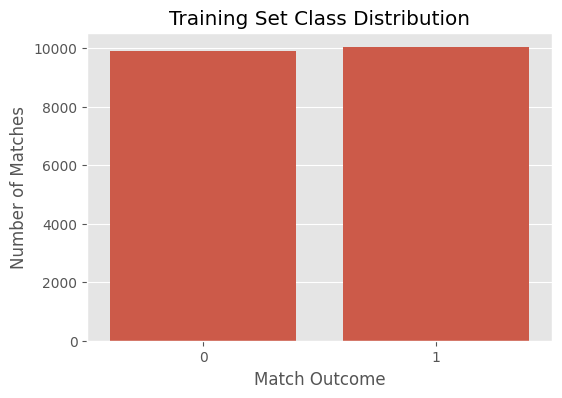

In [4]:
plt.figure(figsize=(6, 4))

sns.countplot(x=y_train)

plt.xlabel("Match Outcome")
plt.ylabel("Number of Matches")
plt.title("Training Set Class Distribution")

plt.show()

# 4. Data Leakage Check

In [5]:
print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

print("Total samples:", len(X_train) + len(X_test))

Training samples: 19929
Test samples: 4983
Total samples: 24912


# 5. Baseline Model

In [6]:
baseline = DummyClassifier(
    strategy="most_frequent"
)

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)
baseline_proba = baseline.predict_proba(X_test)[:, 1]

print(
    "Baseline Accuracy:",
    accuracy_score(y_test, baseline_pred)
)

print(
    "Baseline ROC-AUC:",
    roc_auc_score(y_test, baseline_proba)
)

Baseline Accuracy: 0.5033112582781457
Baseline ROC-AUC: 0.5


# 6. Model Selection

In [7]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]),

    "Decision Tree": Pipeline([
        ("scaler", StandardScaler()),
        ("model", DecisionTreeClassifier(
            max_depth=6,
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestClassifier(
            n_estimators=200,
            max_depth=12,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "Gradient Boosting": Pipeline([
        ("scaler", StandardScaler()),
        ("model", HistGradientBoostingClassifier(
            max_iter=200,
            learning_rate=0.1,
            max_leaf_nodes=31,
            random_state=42
        ))
    ]),

    "Neural Network": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            solver="adam",
            max_iter=300,
            early_stopping=True,
            random_state=42
        ))
    ])
}

# 7. Cross Validation

In [8]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [9]:
results = []

for name, model in models.items():

    cv_results = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    results.append({
        "Model": name,
        "Accuracy": cv_results["test_accuracy"].mean(),
        "Precision": cv_results["test_precision"].mean(),
        "Recall": cv_results["test_recall"].mean(),
        "F1": cv_results["test_f1"].mean(),
        "ROC-AUC": cv_results["test_roc_auc"].mean()
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "ROC-AUC",
    ascending=False
)


# 8. Model Comparison Results

In [10]:
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.722414,0.722381,0.728440,0.725392,0.802395
2,Random Forest,0.723218,0.721181,0.733824,0.727425,0.799586
4,Neural Network,0.718701,0.717134,0.728838,0.722804,0.797685
3,Gradient Boosting,0.721110,0.720215,0.729338,0.724719,0.797279
1,Decision Tree,0.714737,0.701293,0.755158,0.727010,0.785819


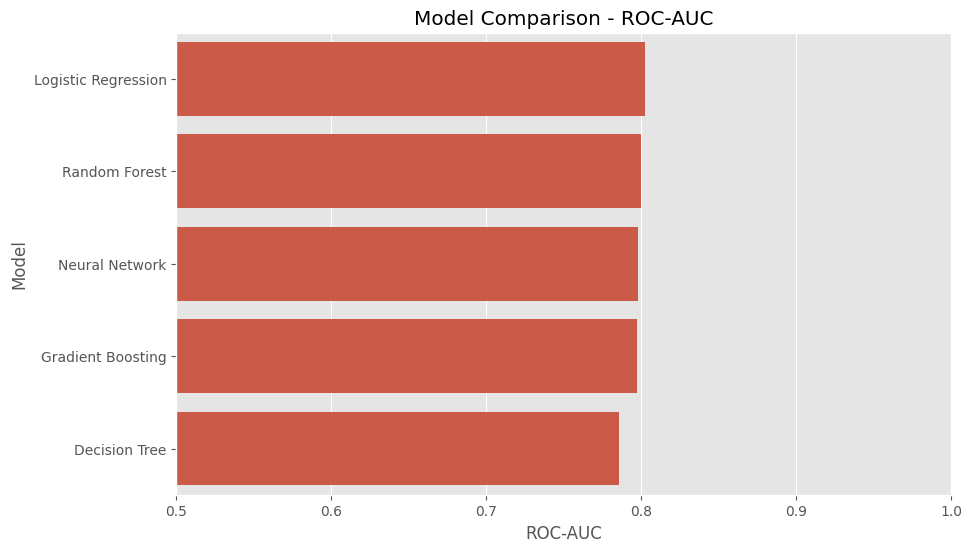

In [11]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="ROC-AUC",
    y="Model"
)

plt.xlabel("ROC-AUC")
plt.ylabel("Model")
plt.title("Model Comparison - ROC-AUC")

plt.xlim(0.5, 1.0)

plt.show()

# 9. Result

In [12]:
best_model_name = results_df.iloc[0]["Model"]

print("Best model:", best_model_name)

Best model: Logistic Regression


# 10. Training the Best Model

In [13]:
best_model = models[best_model_name]

best_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

# 11. Final Evaluation on Test Set

In [14]:
y_pred = best_model.predict(X_test)

y_proba = best_model.predict_proba(
    X_test
)[:, 1]

# 12. Final Evaluation

In [15]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

Accuracy:  0.7307
Precision: 0.7339
Recall:    0.7293
F1-score:  0.7316
ROC-AUC:   0.8065


# 13. Classification Report

In [16]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Loss", "Win"]
    )
)

              precision    recall  f1-score   support

        Loss       0.73      0.73      0.73      2475
         Win       0.73      0.73      0.73      2508

    accuracy                           0.73      4983
   macro avg       0.73      0.73      0.73      4983
weighted avg       0.73      0.73      0.73      4983



# 14. Confusion Matrix

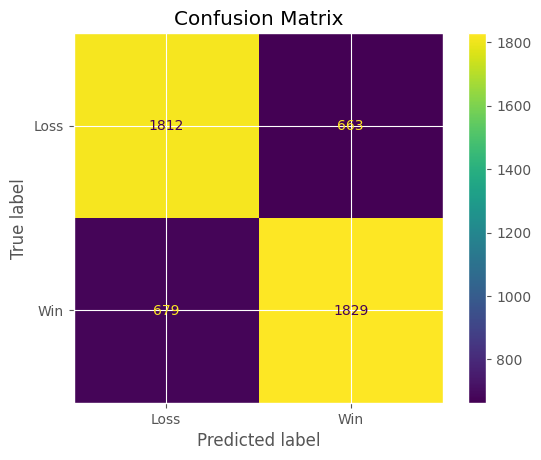

In [17]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Loss", "Win"]
)

disp.plot()

plt.title("Confusion Matrix")
plt.show()

# 15. ROC Curve

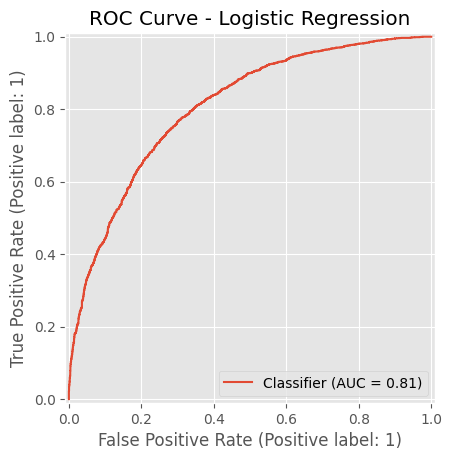

In [18]:
RocCurveDisplay.from_predictions(
    y_test,
    y_proba
)

plt.title(
    f"ROC Curve - {best_model_name}"
)

plt.show()

# 16. Precision-Recall Curve

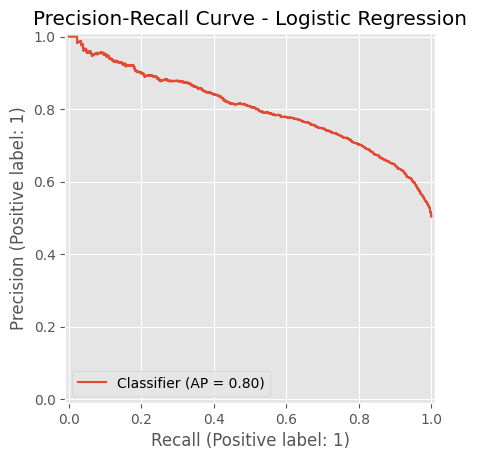

In [19]:
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_proba
)

plt.title(
    f"Precision-Recall Curve - {best_model_name}"
)

plt.show()

# 17. Feature Importance

Top 15 features:
goldDiff                   0.960593
expDiff                    0.450940
lostWaterDrake            -0.143780
lostFireDrake             -0.126354
killedFireDrake            0.125368
destroyedBotInnerTurret    0.118368
killedWaterDrake           0.101660
lostEarthDrake            -0.085294
lostBotNexusTurret        -0.074945
lostAirDrake              -0.072129
lostMidInnerTurret        -0.069193
killedEarthDrake           0.068600
killedAirDrake             0.057809
lostBotInnerTurret         0.057706
lostBotBaseTurret         -0.053750
dtype: float64


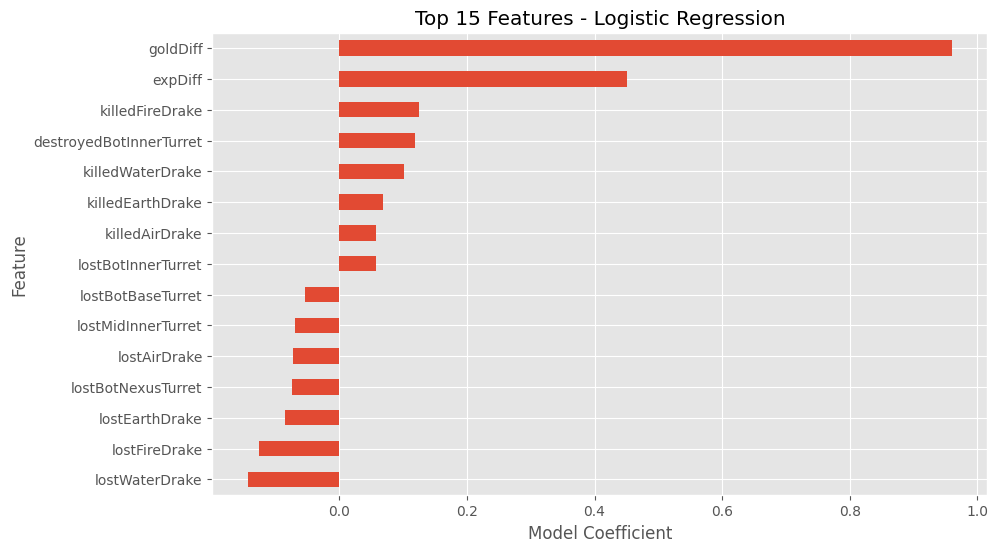

In [20]:
model = best_model.named_steps["model"]

if hasattr(model, "coef_"):

    feature_importance = pd.Series(
        model.coef_[0],
        index=X_train.columns
    )

    feature_importance = feature_importance.sort_values(
        key=abs,
        ascending=False
    )

    print("Top 15 features:")
    print(feature_importance.head(15))

    plt.figure(figsize=(10, 6))

    feature_importance.head(15).sort_values().plot(
        kind="barh"
    )

    plt.xlabel("Model Coefficient")
    plt.ylabel("Feature")
    plt.title(
        f"Top 15 Features - {best_model_name}"
    )

    plt.show()

elif hasattr(model, "feature_importances_"):

    feature_importance = pd.Series(
        model.feature_importances_,
        index=X_train.columns
    )

    feature_importance = feature_importance.sort_values(
        ascending=False
    )

    print("Top 15 features:")
    print(feature_importance.head(15))


else:

    print(
        f"{best_model_name} does not provide "
        "direct feature importance."
    )

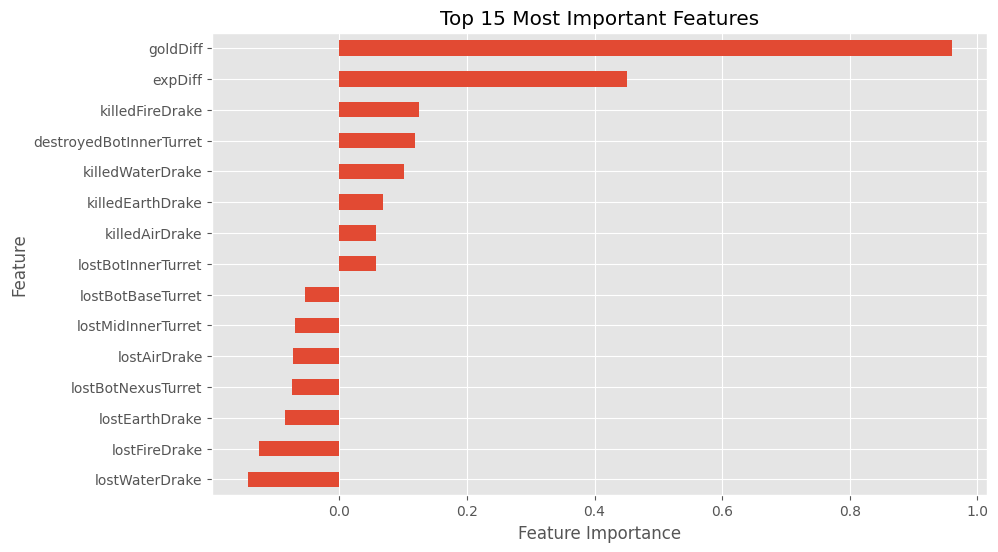

In [21]:
plt.figure(figsize=(10, 6))

feature_importance.head(15).sort_values().plot(
    kind="barh"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Most Important Features")

plt.show()

# 18. Save Final Model

In [22]:
joblib.dump(
    best_model,
    "../models/best_model.pkl"
)

print("Best model saved:", best_model_name)

Best model saved: Logistic Regression


## Conclusions

The objective of this project was to investigate whether the winner of a League of Legends match can be predicted using information available after the first 10 minutes of gameplay.

Several supervised learning algorithms were compared using 5-fold cross-validation. The final model was then evaluated on an unseen test set using accuracy, precision, recall, F1-score, ROC-AUC, a confusion matrix, ROC curve and precision-recall curve.

The best-performing model achieved a ROC-AUC of approximately 0.802408 on the test set.

The results indicate that information available after 10 minutes contains predictive information about the eventual match outcome.

The most influential features were goldDiff, expDiff killedFireDrake, suggesting that factors such as gold difference, experience difference, kills and objectives can provide useful information about the state of a match.

However, the model does not predict the outcome with complete certainty. League of Legends is sometimes unpredictable, and events occurring after the 10-minute mark can significantly change the outcome of a game and in reality any turn of events could also change the result of the game. The model should therefore be interpreted as a probability-based prediction rather than a guaranteed prediction of the winner.